<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1814 | Val: 441 | Test: 252


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 16, accumulation steps = 8 (effective batch size ≈ 128, tuned value = 121)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 8 micro-batches per optimizer step (effective batch size ≈ micro_batch x 8).


[ResNet-50] Epoch   1/100 | LR: 2.68e-05 | train loss 1.3789 acc 0.387 | val loss 1.3496 acc 0.388 *


[ResNet-50] Epoch   2/100 | LR: 2.68e-05 | train loss 1.3038 acc 0.384 | val loss 1.1820 acc 0.404 *


[ResNet-50] Epoch   3/100 | LR: 2.68e-05 | train loss 1.2063 acc 0.507 | val loss 1.1017 acc 0.605 *


[ResNet-50] Epoch   4/100 | LR: 2.68e-05 | train loss 1.1416 acc 0.615 | val loss 1.0238 acc 0.612 *


...

[ResNet-50] Epoch  44/100 | LR: 2.68e-06 | train loss 0.1579 acc 0.923 | val loss 0.4645 acc 0.828


[ResNet-50] Epoch  45/100 | LR: 2.68e-06 | train loss 0.1509 acc 0.926 | val loss 0.4785 acc 0.839


[ResNet-50] Epoch  46/100 | LR: 2.68e-06 | train loss 0.1565 acc 0.922 | val loss 0.4780 acc 0.839


[ResNet-50] Epoch  47/100 | LR: 2.68e-06 | train loss 0.1628 acc 0.920 | val loss 0.4742 acc 0.830


[ResNet-50] Epoch  48/100 | LR: 2.68e-06 | train loss 0.1605 acc 0.924 | val loss 0.4839 acc 0.832

[ResNet-50] No val loss improvement for 10 epochs — stopping early at epoch 48.

[ResNet-50] Restored best checkpoint (val loss = 0.4567)


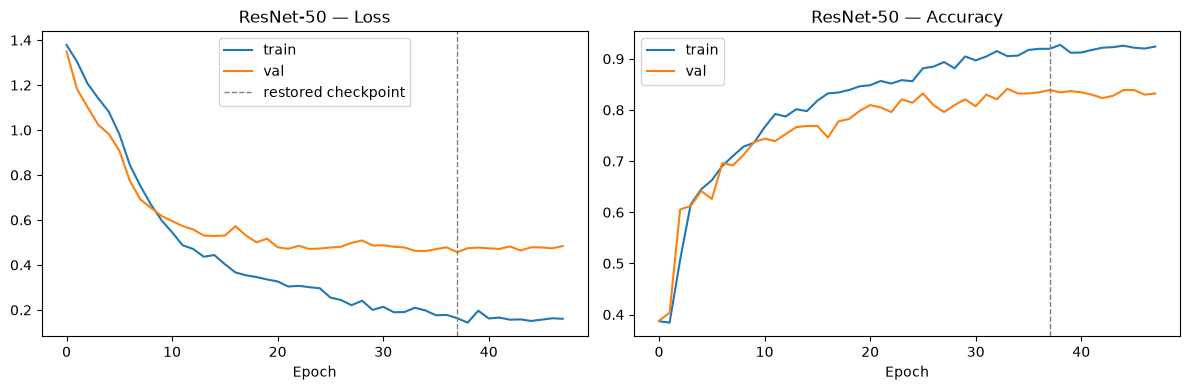

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.738


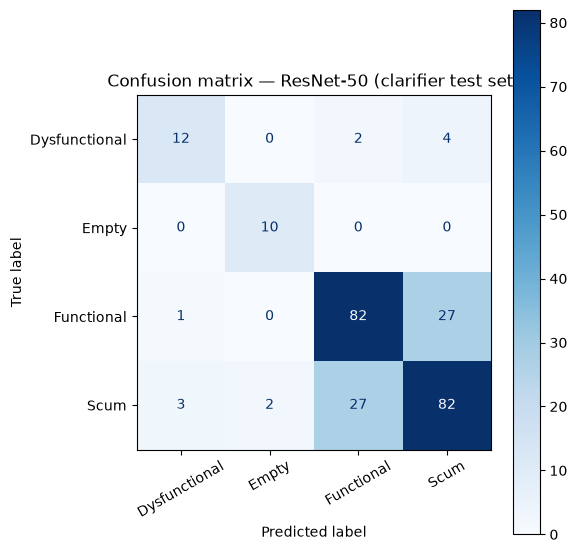

               precision    recall  f1-score   support

Dysfunctional      0.750     0.667     0.706        18
        Empty      0.833     1.000     0.909        10
   Functional      0.739     0.745     0.742       110
         Scum      0.726     0.719     0.722       114

     accuracy                          0.738       252
    macro avg      0.762     0.783     0.770       252
 weighted avg      0.737     0.738     0.737       252



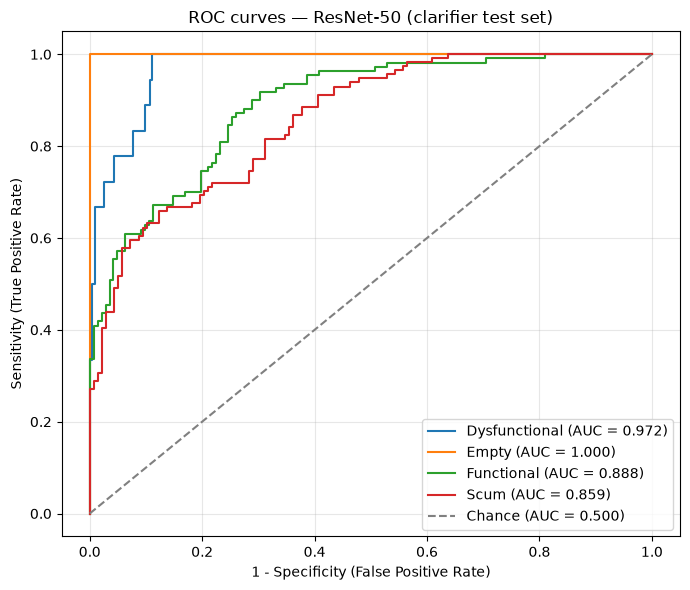

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.972
  Empty          : 1.000
  Functional     : 0.888
  Scum           : 0.859

Mean AUC (over 4/4 classes with test examples): 0.930


(np.float64(0.7380952380952381),
 {'Dysfunctional': 0.9722222222222222,
  'Empty': 1.0,
  'Functional': 0.8878361075544174,
  'Scum': 0.8588227815916603})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/results_clarifier_resnet50_Fisantekraal.pkl
Saved model weights to ../models/clarifier_resnet50_cnn.pt
